# PGC308A — Task I: Exploração dos Dados

**Objetivo:** familiarizar-se com os dados do trace VoD (3600 observações, 1 por segundo).

- **X** (`X.csv`): estatísticas do SO no servidor (9 features)
- **Y** (`Y.csv`): taxa de frames no cliente (`DispFrames`)
- **SLA:** conforme se `DispFrames >= 18` fps

In [2]:
df = load_trace()
features = feature_columns()
target = target_column()

print(f"Observações: {len(df)}")
print(f"Variáveis explicativas (X): {len(features)}")
rename_trace_columns(df).head()

Observações: 3600
Variáveis explicativas (X): 9


,Carimbo de tempo (Unix),CPU ociosa (%),Memória usada (%),Taxa de criação de processos (/s),Taxa de troca de contexto (/s),File handles em uso,Taxa de interrupções (/s),Média de carga — 1 min,Sockets TCP em uso,Taxa de liberação de páginas (/s),Taxa de frames de vídeo (fps)
0,1409264779,0.0,73.03,47.0,62683.0,2496,15802.0,64.17,50,81151.0,17.269999
1,1409264780,0.0,73.04,3.0,67595.0,2496,16139.0,64.17,50,78868.0,22.440000
2,1409264781,0.0,73.05,0.0,69495.0,2496,15753.0,66.15,49,79990.0,24.000000
3,1409264782,0.0,73.06,0.0,67977.0,2496,15849.0,66.15,48,78462.0,20.950001
4,1409264783,0.0,73.06,0.0,69409.0,2496,15789.0,66.15,44,79337.0,15.340001


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Permite importar o pacote src a partir da raiz do projeto
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data import feature_columns, load_trace, target_column
from src.config import FIGURES_DIR, RESULTS_DIR
from src.labels import rename_stat_table, rename_trace_columns

FIGURES_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

## 1. Estatísticas descritivas

Para cada variável de X e Y: **Média**, **Máximo**, **Mínimo**, **Percentil 25**, **Percentil 90** e **Desvio padrão**.

As linhas da tabela indicam a estatística calculada; as colunas descrevem cada métrica do servidor e a taxa de frames no cliente.

In [9]:
cols = features + [target]
stats = df[cols].agg(["mean", "max", "min", lambda s: s.quantile(0.25), lambda s: s.quantile(0.90), "std"])
stats.index = ["mean", "max", "min", "p25", "p90", "std"]

rename_stat_table(stats).round(4)

,CPU ociosa (%),Memória usada (%),Taxa de criação de processos (/s),Taxa de troca de contexto (/s),File handles em uso,Taxa de interrupções (/s),Média de carga — 1 min,Sockets TCP em uso,Taxa de liberação de páginas (/s),Taxa de frames de vídeo (fps)
Média,9.0650,89.1375,7.6833,54045.8740,2656.3333,19978.0407,75.8758,48.9975,72872.1546,18.8184
Máximo,69.5400,97.8400,48.0000,83880.0000,2976.0000,35536.0000,147.4700,87.0000,145874.0000,30.3900
Mínimo,0.0000,73.0300,0.0000,11398.0000,2304.0000,10393.0000,11.1300,21.0000,15928.0000,0.0000
Percentil 25,0.0000,82.9650,0.0000,31302.0000,2496.0000,16678.0000,28.2000,34.0000,61601.7500,13.3900
Percentil 90,38.6210,96.7700,20.0000,72135.1000,2880.0000,28228.4000,127.9930,71.0000,97532.5000,24.6100
Desvio padrão,16.1228,8.1837,8.5326,19497.8115,196.1107,4797.2713,43.8624,15.8712,19504.3212,5.2198


## 2. Quantidades específicas

(a) Observações com uso de memória > 80%  
(b) Média de sockets TCP quando interrupções > 18000/s  
(c) Mínimo de memória quando CPU idle < 20%

In [10]:
mem_col = "X..memused"
idle_col = "all_..idle"
intr_col = "sum_intr.s"
tcp_col = "tcpsck"

q2a = (df[mem_col] > 80).sum()
q2b = df.loc[df[intr_col] > 18000, tcp_col].mean()
q2c = df.loc[df[idle_col] < 20, mem_col].min()

respostas_2 = pd.DataFrame(
    {
        "Item": ["(a)", "(b)", "(c)"],
        "Quantidade calculada": [q2a, round(q2b, 4), round(q2c, 4)],
        "O que significa": [
            "Número de observações com memória usada acima de 80%",
            "Média de sockets TCP quando a taxa de interrupções supera 18.000/s",
            "Menor uso de memória (%) entre observações com CPU ociosa abaixo de 20%",
        ],
    }
)
respostas_2

,Item,Quantidade calculada,O que significa
0,(a),2875.0000,Número de observações com memória usada acima ...
1,(b),46.3473,Média de sockets TCP quando a taxa de interrup...
2,(c),73.0300,Menor uso de memória (%) entre observações com...


## 3. Gráficos

(a) Série temporal: CPU idle (%) e memória usada (%)  
(b) KDE de CPU idle e de memória usada

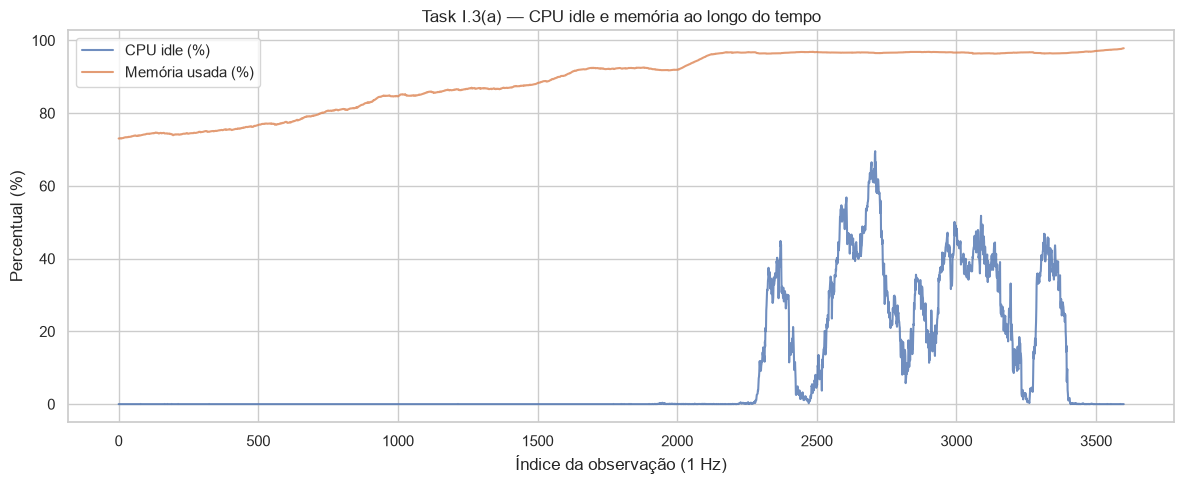

In [11]:
fig, ax = plt.subplots()
ax.plot(df.index, df[idle_col], label="CPU idle (%)", alpha=0.8)
ax.plot(df.index, df[mem_col], label="Memória usada (%)", alpha=0.8)
ax.set_xlabel("Índice da observação (1 Hz)")
ax.set_ylabel("Percentual (%)")
ax.set_title("Task I.3(a) — CPU idle e memória ao longo do tempo")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "task_i_3a_timeseries_cpu_mem.png", dpi=150)
plt.show()

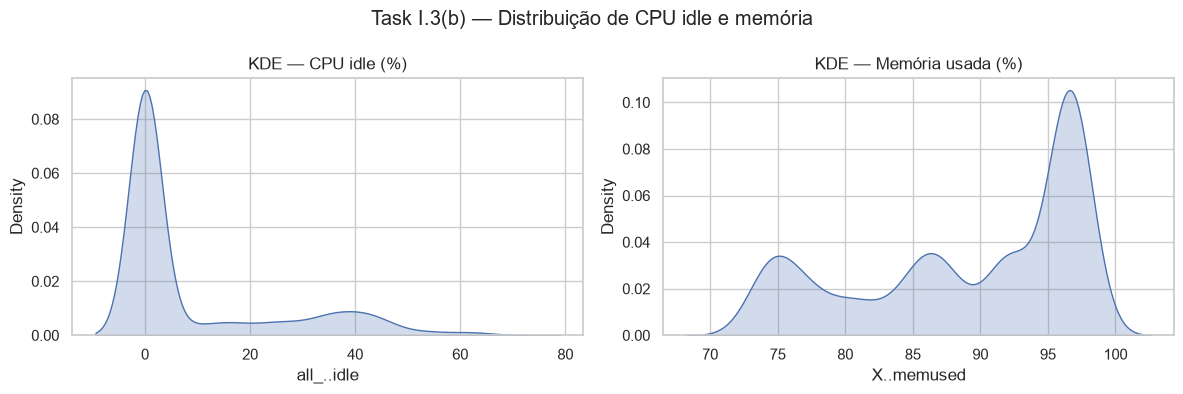

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.kdeplot(df[idle_col], ax=axes[0], fill=True)
axes[0].set_title("KDE — CPU idle (%)")
axes[0].set_xlabel(idle_col)

sns.kdeplot(df[mem_col], ax=axes[1], fill=True)
axes[1].set_title("KDE — Memória usada (%)")
axes[1].set_xlabel(mem_col)

fig.suptitle("Task I.3(b) — Distribuição de CPU idle e memória")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "task_i_3b_kde_cpu_mem.png", dpi=150)
plt.show()